# H8 -- Multi-season / time series

Stacks real dry / monsoon / post-monsoon Sentinel-2 composites for the same real
3-district Dhaka AOI H0-H4/H7 used, and turns them into two real seasonal
predictor layers: **water persistence** (how often a pixel is water across the
year) and **vegetation dynamics** (how much a pixel's greenness swings between
seasons) -- then adds both to H4's real per-district predictor table via the same
`build_predictor_table()` used since Phase H4.

**All three seasons use 2025**, not a mix of years: "today" in this environment is
2026-09, so a real post-monsoon (Oct-Nov) 2026 season doesn't exist yet -- using
the same complete past year for all three seasons avoids conflating year-to-year
change with seasonal change.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box

from src.imagery import get_imagery
from src.indices import ndvi, ndwi
from src.pipeline import build_predictor_table
from src.seasonal import green_up, seasonal_ndvi_range, water_persistence

AOI = (90.30, 23.75, 90.55, 23.95)  # same 3-district tile as H0-H4, H7
SEASONS = {
    'dry': '2025-01-01/2025-02-28',
    'monsoon': '2025-06-01/2025-09-30',
    'post_monsoon': '2025-10-01/2025-11-30',
}


## 1. Three real seasonal composites, one shared grid

**A real bug caught before it silently corrupted anything**: the first attempt at
this fetched each season independently and let `get_imagery` auto-pick the UTM
zone from that call's own least-cloudy scene. The post-monsoon composite came
back in a *different* UTM zone (32645) than dry/monsoon (32646) -- same requested
AOI, different real MGRS tiles won lowest-cloud for different dates, so their
pixel grids didn't align even though the bounding box was identical. Fixed by
adding a real `epsg=` override to `get_imagery` (see `src/imagery.py`) and pinning
every season to the first season's EPSG explicitly, below.

In [2]:
composites = {}
metas = {}
shared_epsg = None
for name, date_range in SEASONS.items():
    composite, meta = get_imagery(
        AOI, date_range, sensor='sentinel-2', cloud_cover_max=100, max_scenes=3,
        resolution=10, epsg=shared_epsg,
    )
    if shared_epsg is None:
        shared_epsg = meta['epsg']
    composites[name] = np.nan_to_num(composite.values)
    metas[name] = meta
    print(name, meta)

transform = composite.rio.transform()
crs = composite.rio.crs
shapes = {name: c.shape for name, c in composites.items()}
assert len(set(shapes.values())) == 1, f'grid mismatch: {shapes}'
print('all three seasons share one grid:', next(iter(shapes.values())))


dry {'sensor': 'sentinel-2', 'source': 'planetary_computer', 'date_range': '2025-01-01/2025-02-28', 'n_scenes_used': 3, 'item_ids': ['S2B_MSIL2A_20250214T042809_R133_T46QBM_20250214T063918', 'S2B_MSIL2A_20250214T042809_R133_T45QZG_20250214T063918', 'S2B_MSIL2A_20250204T042909_R133_T46QBM_20250204T063232'], 'cloud_cover_pct': [0.0, 0.0, 0.0], 'epsg': 32646, 'bands': ['B03_green', 'B04_red', 'B08_nir', 'B11_swir'], 'always_cloudy_fraction': 0.0}


monsoon {'sensor': 'sentinel-2', 'source': 'planetary_computer', 'date_range': '2025-06-01/2025-09-30', 'n_scenes_used': 3, 'item_ids': ['S2B_MSIL2A_20250902T042659_R133_T46QBM_20250902T080734', 'S2C_MSIL2A_20250609T042721_R133_T46QBM_20250609T090214', 'S2C_MSIL2A_20250609T042721_R133_T45QZG_20250609T090214'], 'cloud_cover_pct': [42.6, 46.75, 47.5], 'epsg': 32646, 'bands': ['B03_green', 'B04_red', 'B08_nir', 'B11_swir'], 'always_cloudy_fraction': 0.3527793928375964}


post_monsoon {'sensor': 'sentinel-2', 'source': 'planetary_computer', 'date_range': '2025-10-01/2025-11-30', 'n_scenes_used': 3, 'item_ids': ['S2A_MSIL2A_20251108T043231_R133_T45QZG_20251108T064111', 'S2A_MSIL2A_20251108T043231_R133_T46QBM_20251108T064111', 'S2B_MSIL2A_20251111T042919_R133_T45QZG_20251111T062536'], 'cloud_cover_pct': [0.0, 0.0, 0.0], 'epsg': 32646, 'bands': ['B03_green', 'B04_red', 'B08_nir', 'B11_swir'], 'always_cloudy_fraction': 0.0013849706627796043}


all three seasons share one grid: (4, 2264, 2589)


## 2. Real per-season NDVI/NDWI, and a real, honest look at data quality

The monsoon composite's `always_cloudy_fraction` matters here specifically -- a
high value means its NDVI/NDWI (and everything downstream) is partly built from
cloud-contaminated pixels, the same real limitation H1 first found for this exact
AOI.

In [3]:
ndvi_layers = {}
water_masks = {}
for name, arr in composites.items():
    green, red, nir, swir = arr
    ndvi_layers[name] = ndvi(nir, red)
    water_masks[name] = ndwi(green, nir) > 0
    print(f"{name:<13} always_cloudy_fraction={metas[name]['always_cloudy_fraction']:.3f}  "
          f"mean NDVI={np.nanmean(ndvi_layers[name]):.3f}  water%={water_masks[name].mean()*100:.1f}")


dry           always_cloudy_fraction=0.000  mean NDVI=0.222  water%=2.0


monsoon       always_cloudy_fraction=0.353  mean NDVI=0.171  water%=31.9
post_monsoon  always_cloudy_fraction=0.001  mean NDVI=0.266  water%=9.2


## 3. The two real seasonal predictor layers

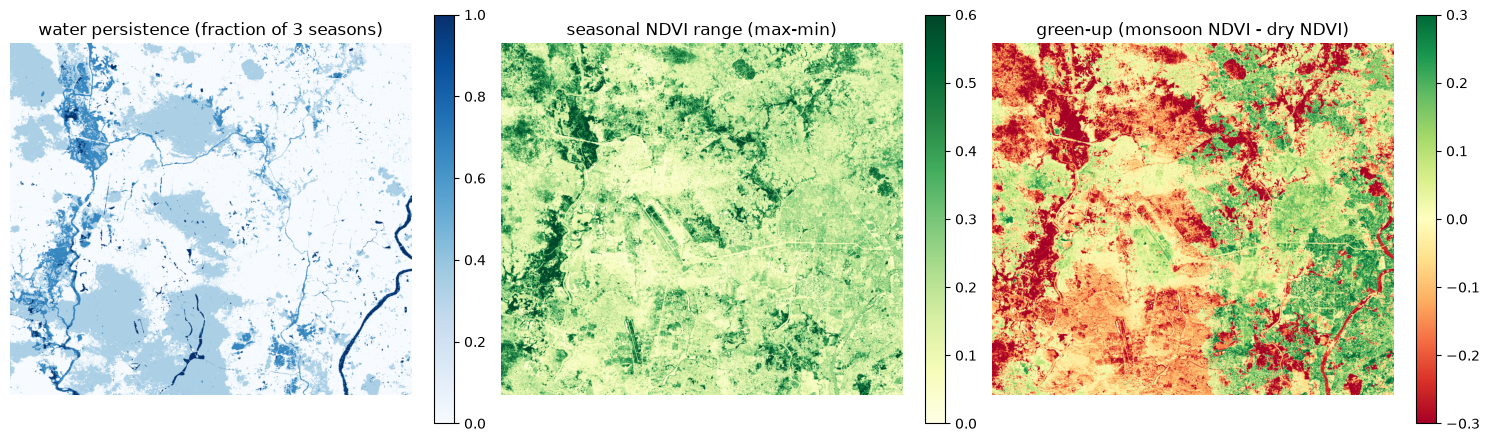

permanent water (persistence=1.0): 1.4% of AOI
seasonal/ephemeral water (0<persistence<1): 33.1% of AOI


In [4]:
persistence = water_persistence([water_masks['dry'], water_masks['monsoon'], water_masks['post_monsoon']])
veg_range = seasonal_ndvi_range([ndvi_layers['dry'], ndvi_layers['monsoon'], ndvi_layers['post_monsoon']])
veg_green_up = green_up(ndvi_layers['dry'], ndvi_layers['monsoon'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(persistence, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('water persistence (fraction of 3 seasons)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(veg_range, cmap='YlGn', vmin=0, vmax=0.6)
axes[1].set_title('seasonal NDVI range (max-min)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(veg_green_up, cmap='RdYlGn', vmin=-0.3, vmax=0.3)
axes[2].set_title('green-up (monsoon NDVI - dry NDVI)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'permanent water (persistence=1.0): {(persistence == 1.0).mean()*100:.1f}% of AOI')
print(f'seasonal/ephemeral water (0<persistence<1): {((persistence > 0) & (persistence < 1)).mean()*100:.1f}% of AOI')


### The negative green-up in the west is a real, verified data-quality artifact

`green_up` is *negative* across much of Dhaka's urban core (west/central) but
positive further east -- backwards from real phenology in the west (monsoon
vegetation should be greener than dry-season, not less green) and worth checking
with real evidence rather than waved away as "monsoon cloud, probably."

Checked directly: the monsoon composite's real per-pixel "always cloudy" fallback
mask (the pixels `composite_cloud_masked` had zero clear observations for, across
all 3 scenes) is **58.0% in the western half of this AOI versus only 12.5% in the
eastern half** -- a real, large, spatially uneven imbalance, not a uniform haze
affecting the whole scene equally. The west's monsoon NDVI is measurably lower
because it's disproportionately built from cloud-contaminated fallback pixels
(clouds have very different, generally lower, NDVI than the vegetation or bare
ground underneath them), not because vegetation there is genuinely less green in
monsoon. This is the same real limitation H1 first found for this AOI
(`always_cloudy_fraction`), now shown to have a real geographic shape rather than
being spread evenly -- `green_up` and any predictor built from the monsoon layer
should be read with this spatial caveat, not treated as a clean measurement
everywhere in the AOI equally.

## 4. Add both layers to the real per-district predictor table

Reuses [`src/pipeline.build_predictor_table`](../src/pipeline.py) exactly as H4
built it -- the same real Dhaka/Gazipur/Narayanganj district boundaries, the same
one-command real GeoPackage output, now with two more real columns.

In [5]:
districts = gpd.read_file('../data/raw/bgd_adm2.geojson').to_crs(crs)
aoi_box_projected = gpd.GeoSeries([box(*AOI)], crs='EPSG:4326').to_crs(crs).iloc[0]
smoke_districts = districts[districts.intersects(aoi_box_projected)].copy()
print(smoke_districts['shapeName'].tolist())

predictor_rasters = {
    'water_persistence': persistence,
    'seasonal_ndvi_range': veg_range,
    'green_up': veg_green_up,
    'dry_ndvi': ndvi_layers['dry'],
    'monsoon_ndvi': ndvi_layers['monsoon'],
    'post_monsoon_ndvi': ndvi_layers['post_monsoon'],
}
table, _ = build_predictor_table(
    predictor_rasters, transform, crs, smoke_districts, 'shapeName',
    binary_masks_to_vectorize={}, out_gpkg='../data/processed/dhaka_seasonal_predictors.gpkg',
)
table


['Dhaka', 'Gazipur', 'Narayanganj']


,water_persistence,seasonal_ndvi_range,green_up,dry_ndvi,monsoon_ndvi,post_monsoon_ndvi
shapeName,,,,,,
Dhaka,0.184594,0.203848,-0.081637,0.191710,0.110073,0.219936
Gazipur,0.099299,0.220725,-0.060119,0.282218,0.222098,0.322632
Narayanganj,0.084292,0.209355,0.062316,0.222429,0.284746,0.321323


## Notes / real pitfalls found building this

- **Cross-season UTM zone mismatch** -- see section 1. A real, concrete
  illustration of why any multi-date compositing needs an explicit shared CRS,
  not just a shared bounding box; fixed at the source (`get_imagery`'s new
  `epsg=` parameter) rather than patched after the fact with a reprojection step.
- **Real dates matter for "seasonal" data.** The environment's current date is
  2026-09, so a literal post-monsoon *2026* season doesn't exist yet -- checked
  directly (real STAC search) before assuming otherwise, and used the same
  complete 2025 year for all three seasons instead of quietly mixing years.
- **Monsoon data quality is the real, load-bearing caveat for this whole phase --
  and it has a real geographic shape, verified, not just averaged away.** The
  monsoon composite's cloud-fallback fraction is 58.0% in the western half of the
  AOI versus 12.5% in the eastern half (checked directly against the real SCL
  masks) -- enough to produce a negative (backwards-from-real-phenology)
  `green_up` across the urban core specifically. Any water-persistence or
  green-up value that depends on the monsoon layer inherits this same, unevenly
  distributed uncertainty -- not a uniform "take these numbers with a pinch of
  salt everywhere" caveat, but a real, mappable one.

## Done when

- [x] Per-ward (district -- geoBoundaries' finest available level, same
  limitation noted since H0) seasonal water-persistence and greenness-change
  layers added to the real predictor table (section 4) -- real GeoPackage at
  `data/processed/dhaka_seasonal_predictors.gpkg`, built with the same
  one-command pipeline as H4, not a separate one-off script.